# Homework: Module 6

In this homework, we'll explore key concepts from generative AI, including GANs, diffusion models, and CLIP. We'll use pre-trained models from Hugging Face to complete various tasks.

## Setup

First, let's install the necessary libraries.

In [1]:
!pip install -q transformers torch torchvision diffusers

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
from diffusers import StableDiffusionPipeline
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


## Part 1: Exploring CLIP

CLIP (Contrastive Language-Image Pre-training) is a model that can understand and compare images and text. Let's use it to perform image-text similarity tasks.

In [3]:
def setup_clip_model():
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    return model.to(device), processor

clip_model, clip_processor = setup_clip_model()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### Task 1: Image-Text Similarity

Complete the following function to compute the similarity between an image and a list of text prompts using CLIP.

In [11]:
from PIL import Image
import requests

def compute_image_text_similarity(model, processor, image, texts):
    inputs = processor(text=texts, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    return outputs.logits_per_image.softmax(dim=1)

# Test your function
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
texts = ["a photo of a cat", "a photo of a dog", "a photo of a giraffe"]

image = Image.open(requests.get(image_url, stream=True).raw)
results = compute_image_text_similarity(clip_model, clip_processor, image, texts)
for (text, score) in zip(texts, results[0]):
  print(f"{text} {score}")

a photo of a cat 0.9926860332489014
a photo of a dog 0.0051426393911242485
a photo of a giraffe 0.0021713220048695803


## Part 2: Exploring Diffusion Models

Diffusion models are a class of generative models that have shown impressive results in image generation. We'll use a pre-trained Stable Diffusion model to generate images from text prompts.

In [12]:
def setup_diffusion_model():
    model_id = "runwayml/stable-diffusion-v1-5"
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
    return pipe.to(device)

diffusion_pipe = setup_diffusion_model()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Task 2: Text-to-Image Generation

Complete the following function to generate images from text prompts using the Stable Diffusion model.

  0%|          | 0/50 [00:00<?, ?it/s]

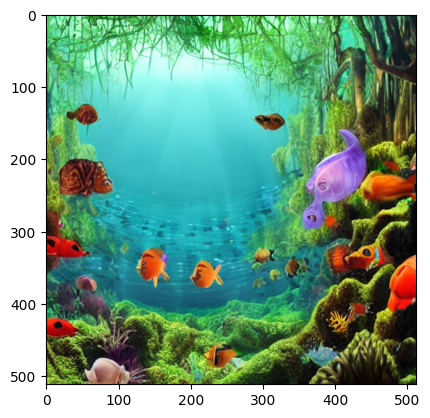

In [14]:
def generate_image_from_text(pipe, prompt, num_images=1):
    output = pipe(prompt=prompt, num_images_per_prompt=num_images)
    return output.images

# Test your function
prompt = "A underwater forest with animals and plants"
for image in generate_image_from_text(diffusion_pipe, prompt):
  plt.imshow(image)

### Task 3: Exploring Guidance Scale

The guidance scale in Stable Diffusion models controls the trade-off between image quality and prompt adherence. Implement a function to compare different guidance scales.

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

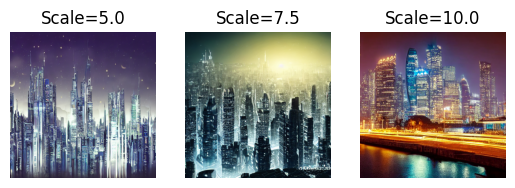

In [16]:
def compare_guidance_scales(pipe, prompt, scales=[5.0, 7.5, 10.0]):
  i = 1
  for scale in scales:
    output = pipe(prompt=prompt, guidance_scale=scale)
    plt.subplot(1, len(scales), i)
    plt.imshow(output.images[0])
    plt.axis('off')
    plt.title(f"Scale={scale}")
    i += 1

# Test your function
prompt = "A futuristic city skyline at night"
compare_guidance_scales(diffusion_pipe, prompt)

## Part 3: Combining CLIP and Diffusion Models

Now, let's combine what we've learned about CLIP and diffusion models to create a more advanced application.

### Task 4: Image Generation and Evaluation

Implement a function that generates an image using the diffusion model and then evaluates how well it matches the original prompt using CLIP.

  0%|          | 0/50 [00:00<?, ?it/s]

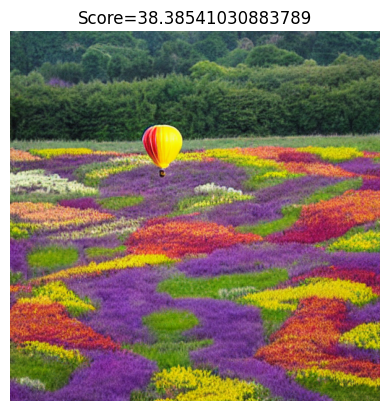

In [18]:
def generate_and_evaluate(diffusion_pipe, clip_model, clip_processor, prompt):
    diffusion_output = diffusion_pipe(prompt=prompt)
    clip_inputs = clip_processor(text=prompt, images=diffusion_output.images[0], return_tensors="pt", padding=True).to(device)
    outputs = clip_model(**clip_inputs)

    plt.imshow(diffusion_output.images[0])
    plt.axis('off')
    plt.title(f"Score={outputs[0][0].item()}")

# Test your function
prompt = "A colorful hot air balloon floating over a field of flowers"
generate_and_evaluate(diffusion_pipe, clip_model, clip_processor, prompt)

## Conclusion

In this homework, you've explored key concepts in generative AI, including:

1. Using CLIP for image-text similarity tasks
2. Generating images with diffusion models
3. Understanding the impact of guidance scale in image generation
4. Combining CLIP and diffusion models for image generation and evaluation

These techniques are fundamental to many advanced applications in computer vision and natural language processing. Keep exploring and experimenting with these powerful models!